#Cargamos el último modelo entrenado e interpretabilidad


In [ ]:
import tensorflow as tf
from tensorflow import keras

# Opción A: Cargar modelo .keras (formato nativo de Keras 3)
modelo = keras.models.load_model('/content/drive/MyDrive/Deep_learning/CNN_taller/modelo_caras_entrenado_keras_2.keras')

# Opción B: Cargar modelo .h5 (formato HDF5)
#modelo = keras.models.load_model('/content/drive/MyDrive/Deep_learning/CNN_taller/modelo_caras_entrenado_2.h5')

# Verificar la arquitectura
modelo.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,906,244 (26.35 MB)

 Trainable params: 3,453,121 (13.17 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 3,453,123 (13.17 MB)

In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np

# Define the path to the image
img_path = "/content/drive/MyDrive/Deep_learning/CNN_taller/Resultados/test/Female Faces/0 (1).jpeg"

# Cargar la imagen
img = image.load_img(img_path, target_size=(150, 150))

# Convertir la imagen a un array de numpy
img_array = image.img_to_array(img)

# Expandir las dimensiones para que coincida con el formato de entrada del modelo (añadir la dimensión del batch)
# El modelo espera una forma (batch_size, 150, 150, 3)
img_array = np.expand_dims(img_array, axis=0)

# Normalizar los píxeles (igual que se hizo con ImageDataGenerator)
img_array /= 255.0

# Realizar la predicción
prediccion = modelo.predict(img_array)

# Interpretar la predicción
# Si class_mode es 'binary', el modelo produce un valor entre 0 y 1.
# Necesitas saber qué clase representa 0 y qué clase representa 1.
# En tu caso, train_generator.class_indices era {'Female Faces': 0, 'Male Faces': 1}
if prediccion[0] > 0.5:
    print(f"Predicción: Hombre (probabilidad: {prediccion[0][0]:.2f})")
else:
    print(f"Predicción: Mujer (probabilidad: {1 - prediccion[0][0]:.2f})")

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Predicción: Mujer (probabilidad: 1.00)


In [ ]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

# =============================================
# 1. VANILLA SALIENCY MAP
# =============================================
def compute_saliency_map(model, img_preprocessed, class_idx):
    img_tensor = tf.convert_to_tensor(img_preprocessed, dtype=tf.float32)
    with tf.GradientTape() as tape:
        tape.watch(img_tensor)
        predictions = model(img_tensor, training=False)
        target_score = predictions[:, class_idx]
    grads = tape.gradient(target_score, img_tensor)
    saliency = tf.reduce_max(tf.abs(grads), axis=-1)
    saliency = (saliency - tf.reduce_min(saliency)) / (tf.reduce_max(saliency) - tf.reduce_min(saliency) + 1e-8)
    return saliency.numpy().squeeze()

# =============================================
# 2. GRAD-CAM (Versión ultra-robusta Keras 3)
# =============================================
def compute_gradcam(model, img_preprocessed, class_idx, last_conv_layer_name):
    # Creamos una entrada simbólica con el tamaño correcto
    img_input = tf.keras.Input(shape=img_preprocessed.shape[1:])

    # Re-mapeamos el modelo para obtener salidas simbólicas
    # Esto es necesario en Keras 3 para modelos Sequential cargados
    x = img_input
    target_layer_output = None

    for layer in model.layers:
        x = layer(x)
        if layer.name == last_conv_layer_name:
            target_layer_output = x

    if target_layer_output is None:
        raise ValueError(f"Capa {last_conv_layer_name} no encontrada.")

    # Definimos el modelo Grad-CAM funcional
    grad_model = tf.keras.Model(inputs=img_input, outputs=[target_layer_output, x])

    img_tensor = tf.convert_to_tensor(img_preprocessed, dtype=tf.float32)

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_tensor)
        target_score = predictions[:, class_idx]

    grads = tape.gradient(target_score, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)
    heatmap = tf.maximum(heatmap, 0)
    heatmap = (heatmap - tf.reduce_min(heatmap)) / (tf.reduce_max(heatmap) - tf.reduce_min(heatmap) + 1e-8)

    return heatmap.numpy()

# =============================================
# 3. AYUDANTE
# =============================================
def find_last_conv_layer(model):
    for layer in reversed(model.layers):
        if isinstance(layer, (tf.keras.layers.Conv2D, tf.keras.layers.SeparableConv2D,
                              tf.keras.layers.DepthwiseConv2D)):
            return layer.name
    raise ValueError("No se encontró ninguna capa convolucional.")

# =============================================
# 4. VISUALIZACIÓN
# =============================================
def visualize_results(original_img, saliency_map, heatmap, class_name, class_idx):
    if original_img.max() <= 1.0:
        original_display = (original_img * 255).astype(np.uint8)
    else:
        original_display = original_img.astype(np.uint8)

    heatmap_resized = cv2.resize(heatmap, (original_display.shape[1], original_display.shape[0]))
    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
    superimposed = cv2.addWeighted(original_display, 0.6, heatmap_colored, 0.4, 0)

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    axes[0].imshow(original_display)
    axes[0].set_title(f'Original: {class_name}')
    axes[0].axis('off')
    axes[1].imshow(saliency_map, cmap='hot')
    axes[1].set_title('Saliency Map')
    axes[1].axis('off')
    axes[2].imshow(superimposed)
    axes[2].set_title('Grad-CAM')
    axes[2].axis('off')
    plt.tight_layout()
    plt.show()

Usando la capa: conv2d_3


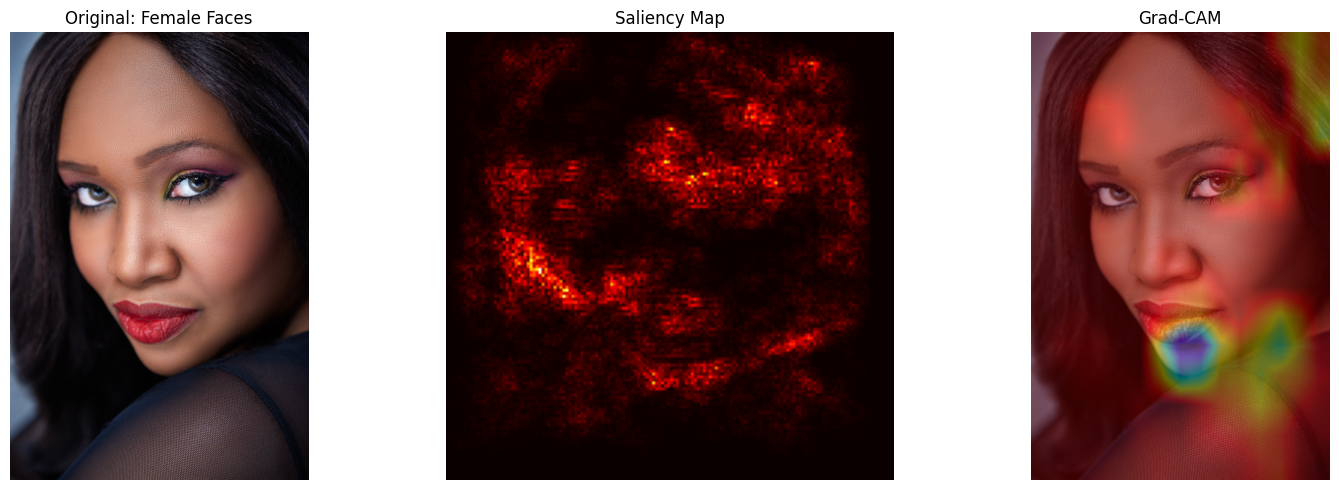

In [ ]:
import cv2

# 1. Cargar imagen original para visualización
img_original = cv2.imread(img_path)
img_original = cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB)

# 2. Determinar el índice de clase predicho
pred_class_idx = 1 if prediccion[0][0] > 0.5 else 0
class_names = ['Female Faces', 'Male Faces']
nombre_clase = class_names[pred_class_idx]

# Asegurar que el modelo tenga definida su entrada llamándolo una vez con los datos
# Esto soluciona el error 'has never been called' en Keras 3
_ = modelo(img_array)

# 3. Calcular Mapas
saliency = compute_saliency_map(modelo, img_array, 0)

last_conv = find_last_conv_layer(modelo)
print(f'Usando la capa: {last_conv}')

# Ejecutamos Grad-CAM
heatmap = compute_gradcam(modelo, img_array, 0, last_conv)

# 4. Visualizar resultados
visualize_results(img_original, saliency, heatmap, nombre_clase, pred_class_idx)